<a href="https://colab.research.google.com/github/sathasivamn/Self-Project---Silver-Micro-Prediction/blob/main/Project_Silver_Micro_Prediction_using_GBRT_and_XGBoost.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Silver Micro Price Prediction using GBRT and XGBoost

In [32]:
#1: Install Required Libraries
!pip install xgboost

In [34]:
#2: Import Standard Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning models and utilities
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score

#  Explanation:
## GradientBoostingRegressor is GBRT from sklearn.
## XGBRegressor is the XGBoost implementation.
## Metrics are used for evaluation.

In [35]:
#3: Load the Dataset
df = pd.read_csv('Silver Micro Futures.csv')

# Show the first few rows
df.head()

,Date,Price,Open,High,Low,Vol.,Change %
0,06-01-2025,"90,573","89,449","91,445","88,801",174.16K,1.41%
1,03-01-2025,"89,314","89,348","90,044","89,001",95.23K,0.10%
2,02-01-2025,"89,224","89,224","89,224","89,224",NaN,1.75%
3,01-01-2025,"87,686","87,356","87,750","87,287",12.82K,0.37%
4,31-12-2024,"87,367","87,536","87,871","87,175",75.48K,-0.34%


In [37]:
# 4: Data Preprocessing (Explore & Clean the Data)
# Check column names and missing values
print(df.info())
print("\nMissing values:\n", df.isnull().sum())

# Summary statistics
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1207 entries, 0 to 1206
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Date      1207 non-null   object
 1   Price     1207 non-null   object
 2   Open      1207 non-null   object
 3   High      1207 non-null   object
 4   Low       1207 non-null   object
 5   Vol.      1185 non-null   object
 6   Change %  1207 non-null   object
dtypes: object(7)
memory usage: 66.1+ KB
None

Missing values:
 Date         0
Price        0
Open         0
High         0
Low          0
Vol.        22
Change %     0
dtype: int64


,Date,Price,Open,High,Low,Vol.,Change %
count,1207,1207,1207,1207,1207,1185,1207
unique,1207,1161,1042,1105,1127,1147,497
top,01-05-2020,"75,012","75,012","75,012","75,012",0.40K,0.00%
freq,1,20,19,19,19,3,26


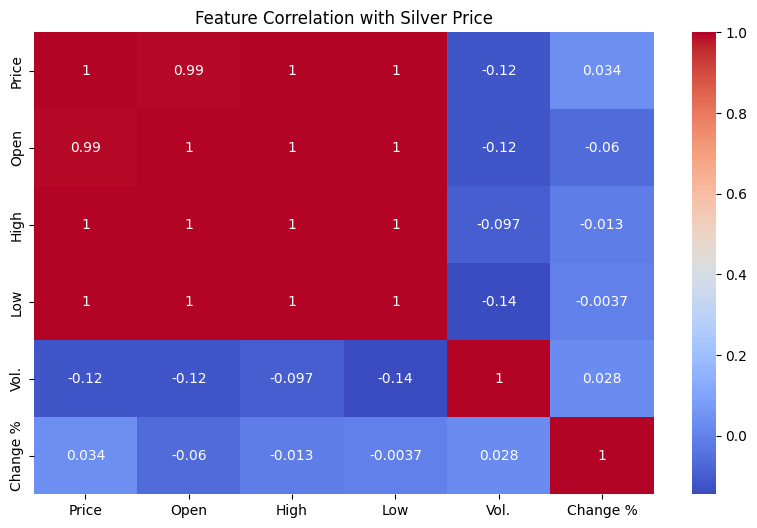

In [45]:
#5: Correlation Heatmap (Feature Engineering & Visualization)
# Plot correlation heatmap
plt.figure(figsize=(10,6))
# Convert 'Date' column to datetime before calculating correlation
# The format was changed from %m-%d-%Y to %d-%m-%Y to fix the error
df['Date'] = pd.to_datetime(df['Date'], format='%d-%m-%Y', errors='coerce') #errors = 'coerce' for invalid parsing

# Exclude 'Date' from correlation calculation

# Convert columns with commas and 'K' to numeric
for column in ['Price', 'Open', 'High', 'Low', 'Vol.']:
    df[column] = df[column].astype(str).str.replace(',', '') #Adding astype(str)
    # Remove 'K' and multiply by 1000 if present
    df[column] = df[column].str.replace('K', '').astype(float)
    df.loc[df[column].astype(str).str.contains('K'), column] *= 1000  # Applying K Handle

# Convert 'Change %' column to numeric by removing '%' and converting to float
df['Change %'] = df['Change %'].str.rstrip('%').astype(float) / 100

sns.heatmap(df.drop('Date', axis=1).corr(), annot=True, cmap='coolwarm')
plt.title('Feature Correlation with Silver Price')
plt.show()

In [52]:
#6: Split Data into Features and Target
# Define features and target
# Use 'Price' as the target column
X = df.drop(['Price', 'Date'], axis=1)  # drop 'Price' which is the target column and 'Date'
y = df['Price']  # target variable

# Impute missing values using the mean (or another strategy)
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy='mean')  # Replace 'mean' with other strategies if needed
X = imputer.fit_transform(X)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [53]:
#7: Train GBRT Model
# Initialize and train GBRT model
gbrt_model = GradientBoostingRegressor(n_estimators=200, learning_rate=0.1, max_depth=3, random_state=42)
gbrt_model.fit(X_train, y_train)

# Predict and evaluate
gbrt_pred = gbrt_model.predict(X_test)
print("GBRT Model Evaluation:")
print("MSE:", mean_squared_error(y_test, gbrt_pred))
print("R2 Score:", r2_score(y_test, gbrt_pred))

GBRT Model Evaluation:
MSE: 135879.37764953924
R2 Score: 0.9987600951080196


In [55]:
#8: Train Extreme Gradient Boosting (XGBoost)
# Initialize and train XGBoost model
xgb_model = XGBRegressor(n_estimators=200, learning_rate=0.1, max_depth=3, random_state=42)
xgb_model.fit(X_train, y_train)

# Predict and evaluate
xgb_pred = xgb_model.predict(X_test)
print("XGBoost Model Evaluation:")
print("MSE:", mean_squared_error(y_test, xgb_pred))
print("R2 Score:", r2_score(y_test, xgb_pred))

XGBoost Model Evaluation:
MSE: 155726.68699904514
R2 Score: 0.9985789875964841


In [59]:
#9: Future Price Prediction (Using a Sample)
# Take a sample row from test set to simulate future prediction
# Instead of using iloc, directly index using integer-based indexing
sample_input = X_test[0].reshape(1, -1)

gbrt_future = gbrt_model.predict(sample_input)[0]
xgb_future = xgb_model.predict(sample_input)[0]

print(f"\n Predicted Silver Price (GBRT): {gbrt_future:.2f}")
print(f" Predicted Silver Price (XGBoost): {xgb_future:.2f}")


 Predicted Silver Price (GBRT): 80994.80
 Predicted Silver Price (XGBoost): 80578.36


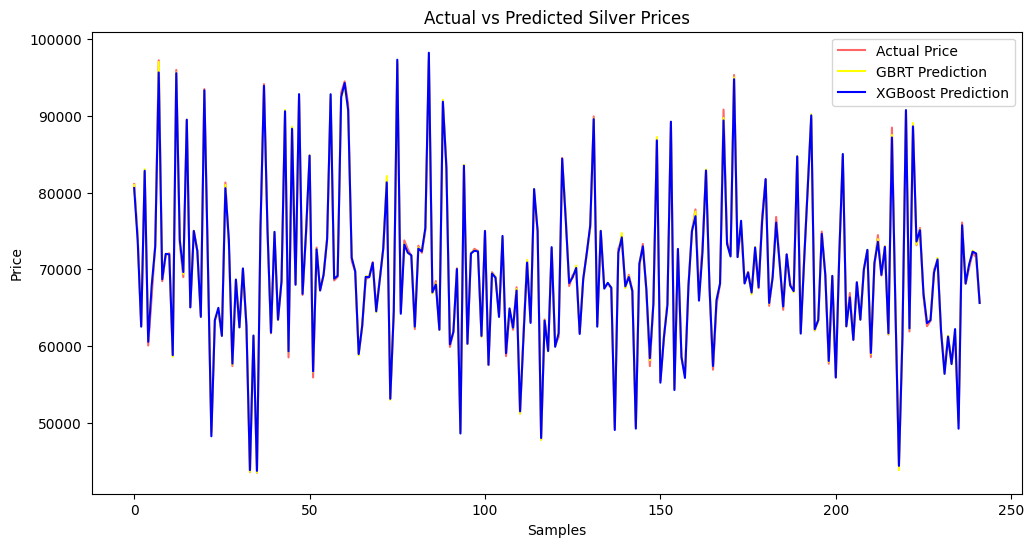

In [63]:
#10: Compare Prediction vs Actual
plt.figure(figsize=(12,6))
plt.plot(y_test.values, label='Actual Price', color='red', alpha=0.6)
plt.plot(gbrt_pred, label='GBRT Prediction', color='yellow')
plt.plot(xgb_pred, label='XGBoost Prediction', color='blue')
plt.title('Actual vs Predicted Silver Prices')
plt.xlabel('Samples')
plt.ylabel('Price')
plt.legend()
plt.show()